# Brightway25 Project Initialization and Database Creation

To override the Brigthway2 directory we need to change the environment variable. 
Here we must change the path and then import the modules from brightway

In [25]:
# Overriding the environment variable to set a new Brightway2 directory
import os
from os import path
new_path = "/Users/vazqueh/Documents/PythonCodes/Drafts/modelInputs/Brightway25_Projects"
os.environ['BRIGHTWAY2_DIR'] = new_path
brightway_db = os.getenv('BRIGHTWAY2_DIR')
print(f'Database path: {brightway_db}')

import bw2data as bd
import bw2io as bi
import bw2calc as bc
import bw2analyzer as bwa

#Other libraries
import pandas as pd
import re
# Plotting
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.sankey import Sankey
from matplotlib.backend_bases import key_press_handler
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg, NavigationToolbar2Tk

Database path: /Users/vazqueh/Documents/PythonCodes/Drafts/modelInputs/Brightway25_Projects


To wacth all the projects in the path selected:

In [17]:
bd.projects

Brightway2 projects manager with 2 objects:
	default
	e_Hydrogen_LCA
Use `projects.report()` to get a report on all projects.

To verify that path of the project:

In [3]:
bd.projects.dir

PosixPath('/Users/vazqueh/Documents/PythonCodes/Drafts/modelInputs/Brightway25_Projects/default.c21f969b')

Select the project to work on:

In [4]:
bd.projects.set_current("e_Hydrogen_LCA")

Check the databases already created in the project selected:

In [10]:
bd.databases

Databases dictionary with 3 object(s):
	e-Hydrogen LCA
	ecoinvent-3.10-biosphere
	ecoinvent_3_10_1_selected_datasets

Visualize the content of a specific database:

In [7]:
fg_db = bd.Database('ecoinvent_3_10_1_selected_datasets')
print(f"The database contains {len(fg_db)} elements.")
print("List of activities in the database:")
for activity in fg_db:
    print(f"Name: {activity['name']}, Unit: {activity['unit']}, Location: {activity['location']}, Code: {activity['code']}")

The database contains 45 elements.
List of activities in the database:
Name: market for tap water, Unit: kilogram, Location: RoW, Code: 62bcd98c1f266525bbac8f861b9a6fe5
Name: market for polymer foaming, Unit: kilogram, Location: GLO, Code: 3640b6afdcc2b45ae8eae5407e6f1aad
Name: market for concrete, 35MPa, Unit: cubic meter, Location: RoW, Code: 371d41d4df35a2a2bad2d3cbe21e5ace
Name: market for battery, Li-ion, LFP, rechargeable, prismatic, Unit: kilogram, Location: GLO, Code: 434e5bf0b30b98374bd7a92ffd1fcc45
Name: market for waste mineral oil, Unit: kilogram, Location: RoW, Code: da9db92bba0999fcdca351ffaefa76c7
Name: tap water production, seawater reverse osmosis, ultrafiltration pretreatment, enhance module, two stages, Unit: kilogram, Location: GLO, Code: 44ad21638339f09c0d2eadd0b15e2b4e
Name: market for copper-rich materials, Unit: kilogram, Location: GLO, Code: 21fd5fdba4a4e53fbb1ec41cbffe2310
Name: market for ethylene glycol, Unit: kilogram, Location: RoW, Code: d6c2b170513060e14

Foreground database:  
First we need to delete the previous foreground database (if already created for previous LCAs)

In [43]:
del bd.databases['e-Hydrogen LCA']

Then its possible to create the foregreound database from the 'e_Hydrogen_LCA.xlsx' file.

In [44]:
fg_db = bi.ExcelImporter('/Users/vazqueh/Documents/PythonCodes/Drafts/modelInputs/e_Hydrogen_LCA.xlsx')
# Match foreground data internally (to itself)
fg_db.apply_strategies()
fg_db.match_database(fields=["name", "unit", "reference product", "location"])
# Match foreground data to Ecoinvent datasets and biosphere
fg_db.match_database('ecoinvent_3_10_1_selected_datasets', fields=["name", "unit", "location", "reference product"])
fg_db.match_database("ecoinvent-3.10-biosphere", fields=["name", "categories", "location"])
fg_db.statistics()  # Display statistics about the matching process
print(list(fg_db.unlinked))
fg_db.write_database()  # Save the foreground database

Extracted 32 worksheets in 0.04 seconds
Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: normalize_biosphere_categories
Applying strategy: normalize_biosphere_names
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 16 strategies in 0.14 seconds
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Graph statistics for `e-Hydrogen LCA` impor

100%|██████████| 32/32 [00:00<00:00, 3870.29it/s]

11:10:14+0300 [info     ] Vacuuming database            


Created database: e-Hydrogen LCA


In [45]:
# Display the final list of databases
print(f"📊 Final databases: {bd.databases}")

📊 Final databases: Databases dictionary with 3 object(s):
	e-Hydrogen LCA
	ecoinvent-3.10-biosphere
	ecoinvent_3_10_1_selected_datasets


Visualize the foreground database:

In [46]:
# Access the foreground database and display its details
fg_db = bd.Database('e-Hydrogen LCA')
print("The imported foreground database is of type {} and has a length of {}.".format(type(fg_db), len(fg_db)))
print("List of activities in the database:")
for activity in fg_db:
    print(f"Name: {activity['name']}, Unit: {activity['unit']}, Location: {activity['location']}, Code: {activity['code']}")


The imported foreground database is of type <class 'bw2data.backends.base.SQLiteBackend'> and has a length of 32.
List of activities in the database:
Name: Steel Construction Element, Unit: unit, Location: GLO, Code: actbop4
Name: Ion Exchange for Water Treatment, Unit: unit, Location: GLO, Code: actbop9
Name: Electricity Production, Photovoltaics, Unit: kilowatt hour, Location: GLO, Code: pv_electricity
Name: Foundation, Unit: unit, Location: GLO, Code: actbop17
Name: Electricity Production, Wind Turbine, Unit: kilowatt hour, Location: GLO, Code: wind_electricity
Name: Tubing and Pump, Unit: unit, Location: GLO, Code: actbop3
Name: Water Gas Separator, Unit: unit, Location: GLO, Code: actbop6
Name: Hydrogen Storage, Type IV, Unit: kilogram, Location: GLO, Code: acthydrogenstorage
Name: Buffertank, Unit: unit, Location: GLO, Code: actbop15
Name: Heat Exchanger, Unit: unit, Location: GLO, Code: actbop10
Name: Back Pressure Regulator, Unit: unit, Location: GLO, Code: actbop8
Name: Electr

In [47]:
# Select one activity from the foreground database by its code
activity_by_code = fg_db.get("plant_operation")
print(activity_by_code)

# Display all exchanges (inputs and outputs) for the selected activity
for exc in activity_by_code.exchanges():
    print(exc)

'Plant Operation, Electrolyser' (unit, GLO, None)
Exchange: 6.381689770584119e-07 unit 'Electrolyser' (unit, GLO, None) to 'Plant Operation, Electrolyser' (unit, GLO, None)>
Exchange: 49.54751131221718 kilowatt hour 'Electricity Production, Photovoltaics' (kilowatt hour, GLO, None) to 'Plant Operation, Electrolyser' (unit, GLO, None)>
Exchange: 0.4524886877828146 kilowatt hour 'Electricity Production, Wind Turbine' (kilowatt hour, GLO, None) to 'Plant Operation, Electrolyser' (unit, GLO, None)>
Exchange: 7.280426223661327e-05 kilogram 'Hydrogen Storage, Type IV' (kilogram, GLO, None) to 'Plant Operation, Electrolyser' (unit, GLO, None)>
Exchange: 0.05 kilogram 'market for battery, Li-ion, LFP, rechargeable, prismatic' (kilogram, GLO, None) to 'Plant Operation, Electrolyser' (unit, GLO, None)>
Exchange: 10 kilogram 'tap water production, seawater reverse osmosis, ultrafiltration pretreatment, enhance module, two stages' (kilogram, GLO, None) to 'Plant Operation, Electrolyser' (unit, GLO

Select the LCIA method

In [48]:
# Select a Life Cycle Impact Assessment (LCIA) method family and method name
selected_method = 'CML v4.8 2016'
gwp_key = [
    m for m in bd.methods if "climate change" == m[1] and selected_method == m[0]
].pop()

# Display details about the selected LCIA method
method_details = bd.methods[gwp_key]
print(f"Method key: {gwp_key}")
print(f"Unit: {method_details.get('unit', 'No unit found')}")


Method key: ('CML v4.8 2016', 'climate change', 'global warming potential (GWP100)')
Unit: kg CO2-Eq


Perform the LCA

In [49]:
# Run the Life Cycle Assessment (LCA)
# Prepare the functional unit and data objects for the LCA
my_functional_unit, data_objs, _ = bd.prepare_lca_inputs(
    {activity_by_code: 1},  # Define the functional unit (1 unit of the selected activity)
    method=gwp_key,         # Use the selected LCIA method
)

# Initialize the LCA object
my_lca = bc.LCA(demand=my_functional_unit, data_objs=data_objs)

# Perform the Life Cycle Inventory (LCI) calculation
my_lca.lci()

# Perform the Life Cycle Impact Assessment (LCIA) calculation
my_lca.lcia()

# Display the final LCA score
print(my_lca.score)

3.068465094795156


Perform a contribution analysis of the result

In [50]:
# Perform a basic contribution analysis
ca=bwa.utils.recursive_calculation_to_object(
    ("e-Hydrogen LCA", "plant_operation"),  # The activity to analyze
    gwp_key,
    amount=1,  # How much of the activity? (same as in our FU)
    max_level=3,  # How many levels deep in the CA do you want to go?
    cutoff=0.00001,  # Cutoff threshold for contributions
)
df = pd.DataFrame(ca)
print(df)

         label    parent     score  fraction        amount  \
0         root      None  3.068465  1.000000  1.000000e+00   
1       root_a      root  0.267755  0.087260  6.381690e-07   
2     root_a_a    root_a  0.065804  0.021445  6.381690e-07   
3   root_a_a_a  root_a_a  0.002441  0.000796  6.381690e-07   
4   root_a_a_b  root_a_a  0.002079  0.000677  6.381690e-07   
5   root_a_a_c  root_a_a  0.001425  0.000464  6.381690e-07   
6   root_a_a_d  root_a_a  0.009136  0.002977  6.381690e-07   
7   root_a_a_e  root_a_a  0.000921  0.000300  6.381690e-07   
8   root_a_a_f  root_a_a  0.000380  0.000124  6.381690e-07   
9   root_a_a_g  root_a_a  0.000907  0.000296  6.381690e-07   
10  root_a_a_h  root_a_a  0.000111  0.000036  6.381690e-07   
11  root_a_a_i  root_a_a  0.000332  0.000108  6.381690e-07   
12  root_a_a_j  root_a_a  0.004397  0.001433  6.381690e-07   
13  root_a_a_k  root_a_a  0.001469  0.000479  6.381690e-07   
14  root_a_a_l  root_a_a  0.001017  0.000332  6.381690e-07   
15  root

Save the contribution analysis in an excel file:

In [51]:
#print(df.to_string())
df.to_csv(path.join('/Users/vazqueh/Documents/PythonCodes/Drafts/modelOutputs',"lca_results.csv"), index=False)

# Load the CSV file into a DataFrame
file_path = path.join('/Users/vazqueh/Documents/PythonCodes/Drafts/modelOutputs',"lca_results.csv")
df = pd.read_csv(file_path)


Generate the sankey diagram :

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


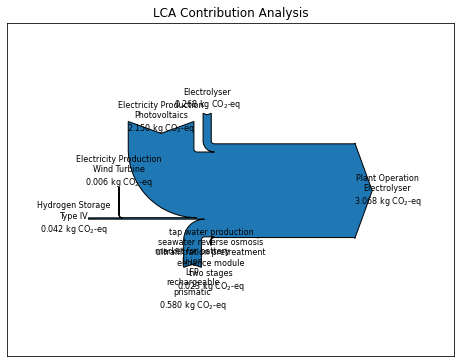

In [56]:
# Prepare the Sankey diagram data
flows = []
labels = []

# Iterate through the rows to define the flows
for index, row in df.iterrows():
    if pd.isna(row['parent']):  # Root node
        flows.append(-row['score'])
        labels.append("\n".join(row['name'].split(", ")))  # Wrap long labels
    elif re.match(r"^root_[a-zA-Z]$", row['label']):  # Include 'root_a', 'root_b', etc.
        flows.append(row['score'])
        labels.append("\n".join(row['name'].split(", ")))  # Wrap long labels


if len(flows) == 5:
    orientations = [0,1,1,0,-1]
    pathlengths = [4,1,1,0.25,0.25]
elif len(flows) == 6:
    orientations = [0,1,1,1,0,-1]
    pathlengths = [4,1,1,1,0.25,0.25]
elif len(flows) == 7:
    orientations = [0,1,1,1,0,-1,-1]
    pathlengths = [4,1,1,1,1,1,0.25]

# Create the Sankey diagram
fig6 = plt.figure(figsize=(8,6), dpi=72)
ax6 = fig6.add_subplot(1,1,1,xticks=[], yticks=[], title="LCA Contribution Analysis")
sankey = Sankey(ax=ax6, offset=0.5, head_angle=140, gap=0.3,
        format='%.3f', unit=' kg CO$_{2}$-eq', margin=2.5)  # Use LaTeX formatting for CO₂

# Add flows and labels to the Sankey diagram
sankey.add(flows=flows, labels=labels, orientations=orientations, pathlengths=pathlengths)

# Finalize and display the diagram
sankey.finish()

# Adjust font size of the labels
for text in ax6.texts:
    text.set_fontsize(8)  # Set the desired font size

canvas6 = FigureCanvasTkAgg(fig6)
canvas6.draw()
